In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Zomato-data-.csv")

In [4]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [5]:
df.shape

(148, 7)

In [6]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   name                         148 non-null    str  
 1   online_order                 148 non-null    str  
 2   book_table                   148 non-null    str  
 3   rate                         148 non-null    str  
 4   votes                        148 non-null    int64
 5   approx_cost(for two people)  148 non-null    int64
 6   listed_in(type)              148 non-null    str  
dtypes: int64(2), str(5)
memory usage: 12.7 KB


In [8]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [9]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)

In [12]:
df['rate'] = df['rate'].apply(handleRate)

In [13]:
df['rate'].head()

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64

In [14]:
df['listed_in(type)'].value_counts()

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

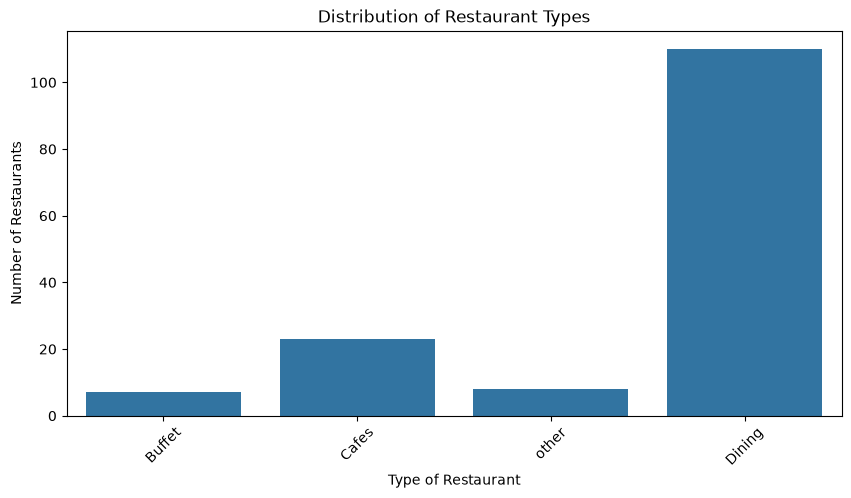

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='listed_in(type)',
    data=df
)

plt.xlabel("Type of Restaurant")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Restaurant Types")

plt.xticks(rotation=45)
plt.show()

In [16]:
votes_by_type = df.groupby(
    'listed_in(type)'
)['votes'].sum().sort_values(ascending=False)

votes_by_type

listed_in(type)
Dining    20363
other      9367
Cafes      6434
Buffet     3028
Name: votes, dtype: int64

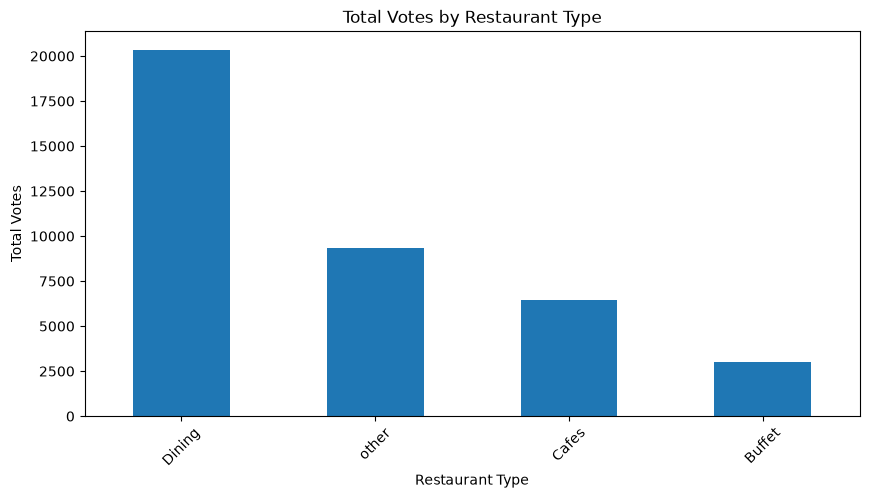

In [17]:
plt.figure(figsize=(10,5))

votes_by_type.plot(
    kind='bar'
)

plt.xlabel("Restaurant Type")
plt.ylabel("Total Votes")
plt.title("Total Votes by Restaurant Type")

plt.xticks(rotation=45)
plt.show()

In [18]:
max_votes = df['votes'].max()

df.loc[
    df['votes'] == max_votes,
    ['name', 'votes']
]

,name,votes
38,Empire Restaurant,4884


In [19]:
df[['name', 'votes']].sort_values(
    by='votes',
    ascending=False
).head(10)

,name,votes
38,Empire Restaurant,4884
86,Meghana Foods,4401
7,Onesta,2556
44,Onesta,2556
65,Kabab Magic,1720
37,Szechuan Dragon,1647
54,Roving Feast,1047
2,San Churro Cafe,918
14,San Churro Cafe,918
67,Gustoes Beer House,868


In [20]:
df['online_order'].value_counts()

online_order
No     90
Yes    58
Name: count, dtype: int64

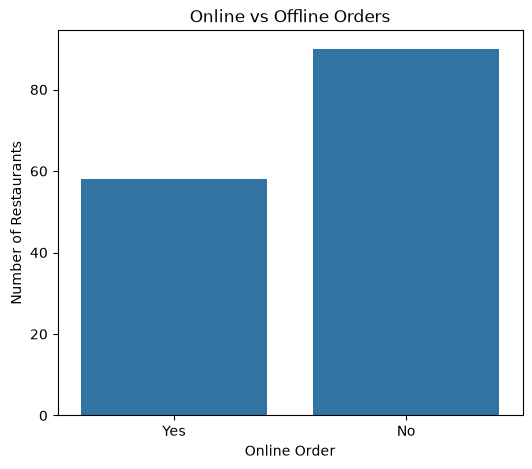

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='online_order',
    data=df
)

plt.xlabel("Online Order")
plt.ylabel("Number of Restaurants")
plt.title("Online vs Offline Orders")

plt.show()

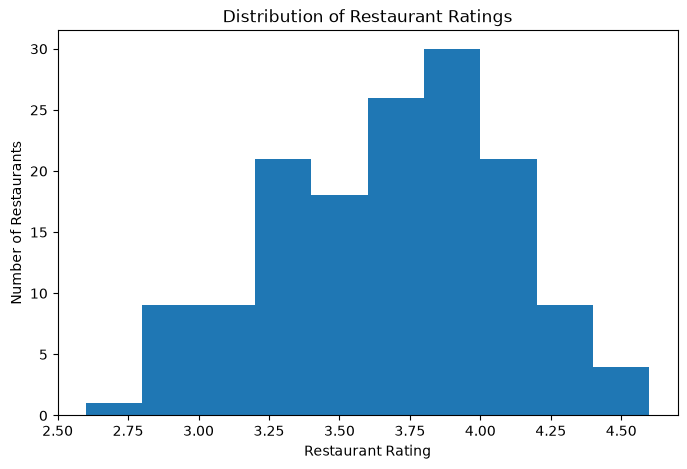

In [22]:
plt.figure(figsize=(8,5))

plt.hist(
    df['rate'],
    bins=10
)

plt.xlabel("Restaurant Rating")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Restaurant Ratings")

plt.show()

In [23]:
df['rate'].mean()

np.float64(3.6331081081081082)

In [24]:
df['rate'].median()

np.float64(3.7)

In [25]:
df['rate'].min()

np.float64(2.6)

In [26]:
df['rate'].max()

np.float64(4.6)

In [27]:
df['approx_cost(for two people)'].value_counts()

approx_cost(for two people)
300    23
200    16
150    16
400    15
500    14
600    13
800    12
450     6
100     6
250     6
700     5
550     3
750     3
350     3
650     2
900     2
850     2
950     1
Name: count, dtype: int64

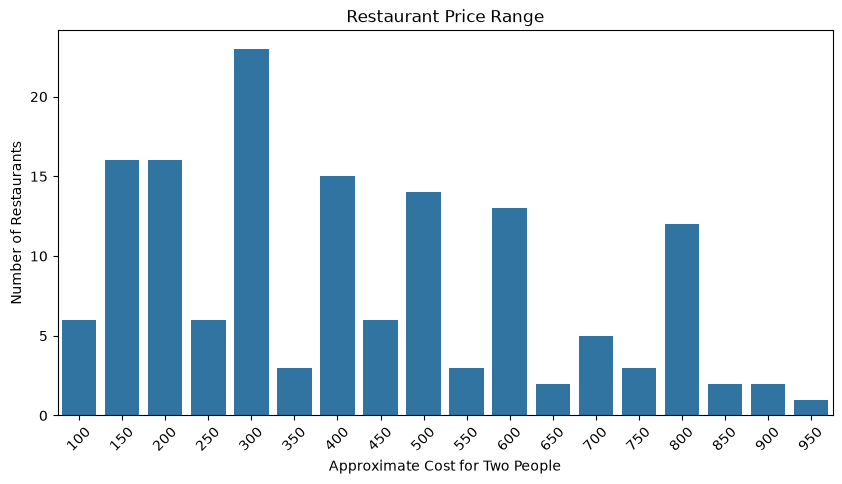

In [28]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='approx_cost(for two people)',
    data=df
)

plt.xlabel("Approximate Cost for Two People")
plt.ylabel("Number of Restaurants")
plt.title("Restaurant Price Range")

plt.xticks(rotation=45)
plt.show()

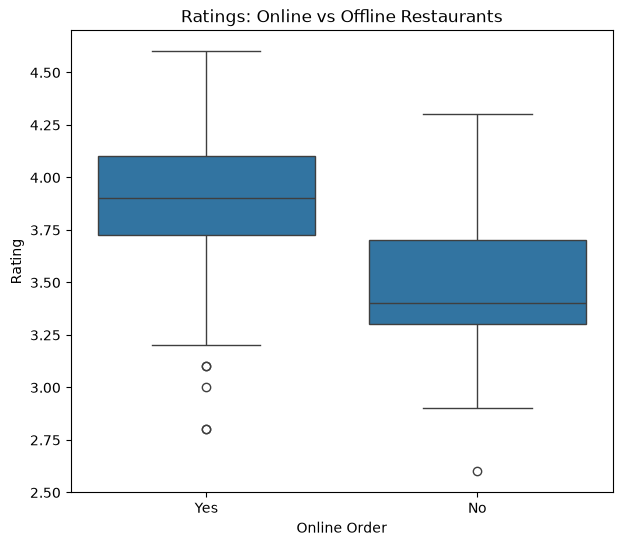

In [29]:
plt.figure(figsize=(7,6))

sns.boxplot(
    x='online_order',
    y='rate',
    data=df
)

plt.xlabel("Online Order")
plt.ylabel("Rating")
plt.title("Ratings: Online vs Offline Restaurants")

plt.show()

In [30]:
pivot_table = df.pivot_table(
    index='listed_in(type)',
    columns='online_order',
    aggfunc='size',
    fill_value=0
)

pivot_table

online_order,No,Yes
listed_in(type),,
Buffet,3,4
Cafes,8,15
Dining,77,33
other,2,6


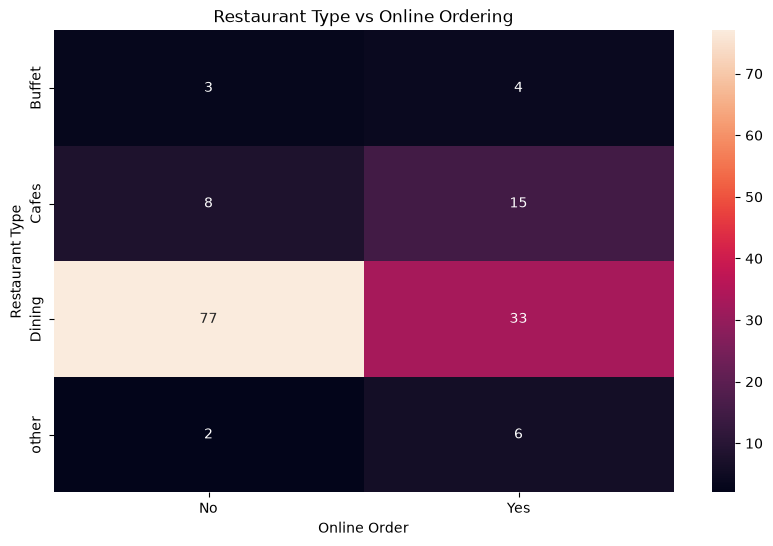

In [31]:
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt='d'
)

plt.xlabel("Online Order")
plt.ylabel("Restaurant Type")
plt.title("Restaurant Type vs Online Ordering")

plt.show()

In [32]:
avg_rating = df.groupby(
    'listed_in(type)'
)['rate'].mean().sort_values(ascending=False)

avg_rating

listed_in(type)
other     3.912500
Buffet    3.842857
Cafes     3.765217
Dining    3.571818
Name: rate, dtype: float64

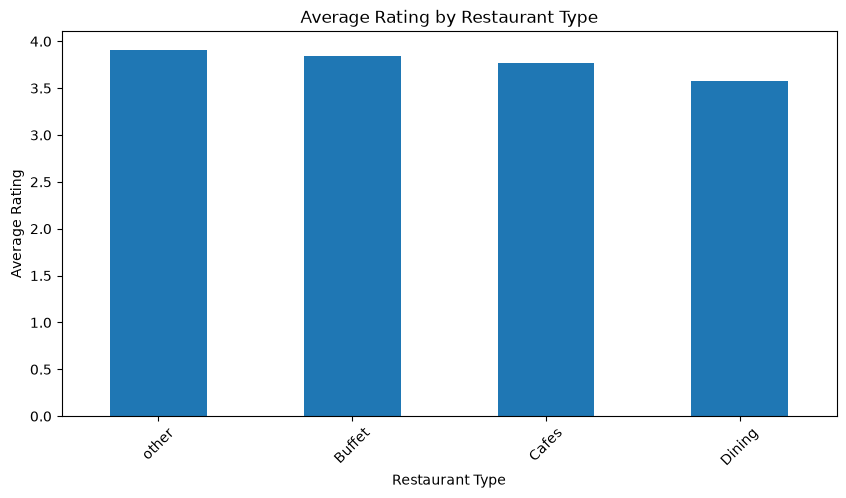

In [33]:
plt.figure(figsize=(10,5))

avg_rating.plot(kind='bar')

plt.xlabel("Restaurant Type")
plt.ylabel("Average Rating")
plt.title("Average Rating by Restaurant Type")

plt.xticks(rotation=45)
plt.show()

In [34]:
df.groupby(
    'approx_cost(for two people)'
)['rate'].mean()

approx_cost(for two people)
100    3.416667
150    3.537500
200    3.525000
250    3.350000
300    3.600000
350    3.333333
400    3.520000
450    3.933333
500    3.714286
550    3.766667
600    3.800000
650    3.850000
700    3.720000
750    4.100000
800    3.791667
850    3.850000
900    3.350000
950    3.700000
Name: rate, dtype: float64

In [35]:
top_10 = df[
    ['name', 'rate', 'votes']
].sort_values(
    by='votes',
    ascending=False
).head(10)

top_10

,name,rate,votes
38,Empire Restaurant,4.4,4884
86,Meghana Foods,4.4,4401
7,Onesta,4.6,2556
44,Onesta,4.6,2556
65,Kabab Magic,4.1,1720
37,Szechuan Dragon,4.2,1647
54,Roving Feast,4.0,1047
2,San Churro Cafe,3.8,918
14,San Churro Cafe,3.8,918
67,Gustoes Beer House,4.1,868


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 12.0 KB


In [37]:
def rating_category(rating):
    if rating < 3:
        return "Poor"
    elif rating < 4:
        return "Average"
    elif rating < 4.5:
        return "Good"
    else:
        return "Excellent"

df['rating_category'] = df['rate'].apply(rating_category)

In [38]:
df[['name', 'rate', 'rating_category']].head(10)

,name,rate,rating_category
0,Jalsa,4.1,Good
1,Spice Elephant,4.1,Good
2,San Churro Cafe,3.8,Average
3,Addhuri Udupi Bhojana,3.7,Average
4,Grand Village,3.8,Average
5,Timepass Dinner,3.8,Average
6,Rosewood International Hotel - Bar & Restaurant,3.6,Average
7,Onesta,4.6,Excellent
8,Penthouse Cafe,4.0,Good
9,Smacznego,4.2,Good


In [39]:
df['rating_category'].value_counts()

rating_category
Average      104
Good          32
Poor          10
Excellent      2
Name: count, dtype: int64

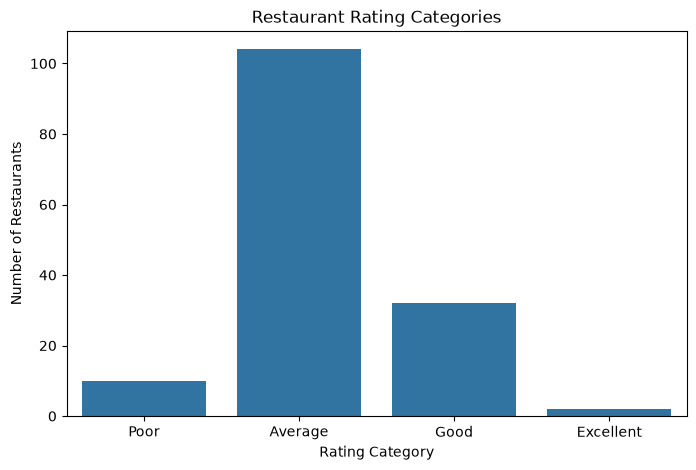

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='rating_category',
    data=df,
    order=['Poor', 'Average', 'Good', 'Excellent']
)

plt.xlabel("Rating Category")
plt.ylabel("Number of Restaurants")
plt.title("Restaurant Rating Categories")

plt.show()

In [41]:
sorted(df['approx_cost(for two people)'].unique())

[np.int64(100),
 np.int64(150),
 np.int64(200),
 np.int64(250),
 np.int64(300),
 np.int64(350),
 np.int64(400),
 np.int64(450),
 np.int64(500),
 np.int64(550),
 np.int64(600),
 np.int64(650),
 np.int64(700),
 np.int64(750),
 np.int64(800),
 np.int64(850),
 np.int64(900),
 np.int64(950)]

In [42]:
def price_category(cost):
    if cost <= 300:
        return "Budget"
    elif cost <= 600:
        return "Mid-Range"
    else:
        return "Premium"

df['price_category'] = df['approx_cost(for two people)'].apply(price_category)

In [43]:
df[['name', 'approx_cost(for two people)', 'price_category']].head(10)

,name,approx_cost(for two people),price_category
0,Jalsa,800,Premium
1,Spice Elephant,800,Premium
2,San Churro Cafe,800,Premium
3,Addhuri Udupi Bhojana,300,Budget
4,Grand Village,600,Mid-Range
5,Timepass Dinner,600,Mid-Range
6,Rosewood International Hotel - Bar & Restaurant,800,Premium
7,Onesta,600,Mid-Range
8,Penthouse Cafe,700,Premium
9,Smacznego,550,Mid-Range


In [44]:
df['price_category'].value_counts()

price_category
Budget       67
Mid-Range    54
Premium      27
Name: count, dtype: int64

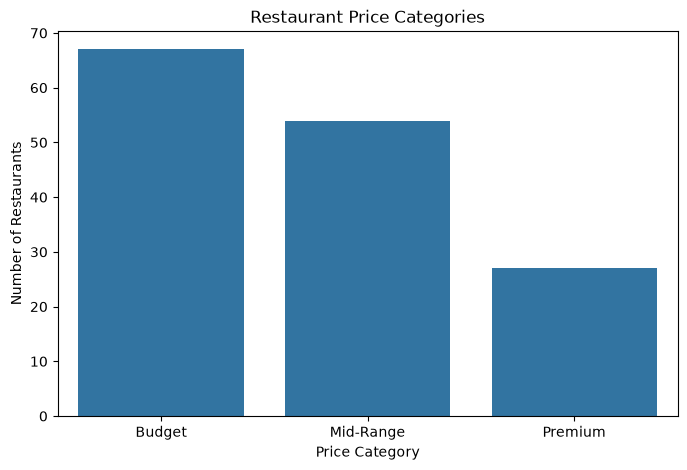

In [45]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='price_category',
    data=df,
    order=['Budget', 'Mid-Range', 'Premium']
)

plt.xlabel("Price Category")
plt.ylabel("Number of Restaurants")
plt.title("Restaurant Price Categories")

plt.show()

In [46]:
price_rating = df.groupby(
    'price_category'
)['rate'].agg(['mean', 'median', 'count'])

price_rating

,mean,median,count
price_category,,,
Budget,3.528358,3.5,67
Mid-Range,3.687037,3.8,54
Premium,3.785185,3.8,27


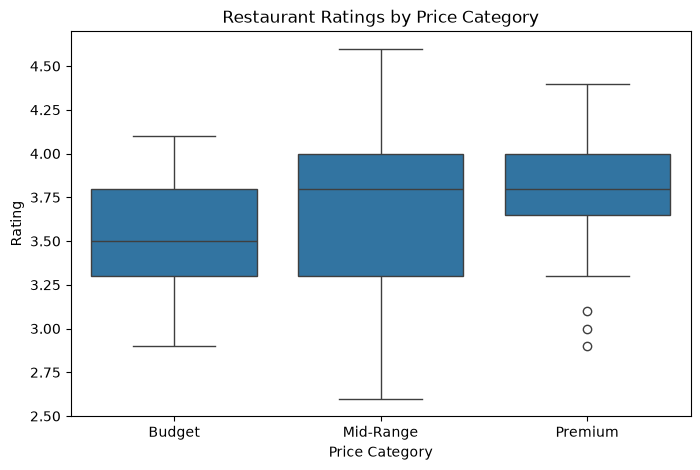

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='price_category',
    y='rate',
    data=df,
    order=['Budget', 'Mid-Range', 'Premium']
)

plt.xlabel("Price Category")
plt.ylabel("Rating")
plt.title("Restaurant Ratings by Price Category")

plt.show()

In [48]:
df[['rate', 'votes']].corr()

,rate,votes
rate,1.000000,0.489844
votes,0.489844,1.000000


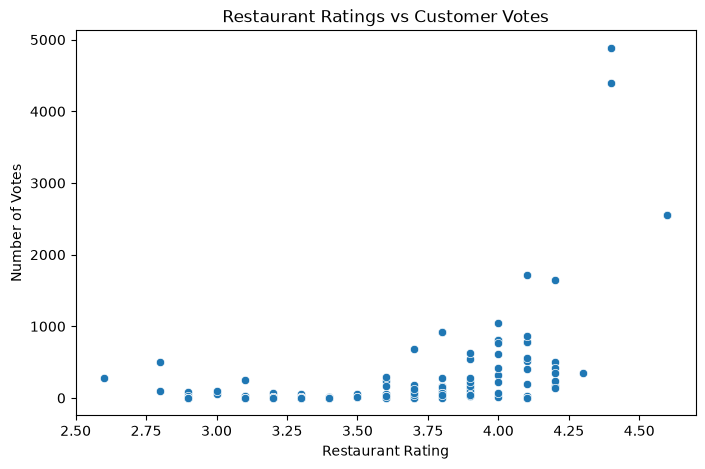

In [49]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='rate',
    y='votes',
    data=df
)

plt.xlabel("Restaurant Rating")
plt.ylabel("Number of Votes")
plt.title("Restaurant Ratings vs Customer Votes")

plt.show()

In [50]:
df['online_order'].value_counts()

online_order
No     90
Yes    58
Name: count, dtype: int64

In [51]:
online_rating = df.groupby(
    'online_order'
)['rate'].agg(['mean', 'median', 'count'])

online_rating

,mean,median,count
online_order,,,
No,3.487778,3.4,90
Yes,3.858621,3.9,58


In [52]:
online_votes = df.groupby(
    'online_order'
)['votes'].agg(['mean', 'median', 'count'])

online_votes

,mean,median,count
online_order,,,
No,75.222222,10.5,90
Yes,559.000000,210.0,58


In [53]:
restaurant_type_analysis = df.groupby(
    'listed_in(type)'
).agg(
    restaurants=('name', 'count'),
    avg_rating=('rate', 'mean'),
    total_votes=('votes', 'sum'),
    avg_votes=('votes', 'mean'),
    avg_cost=('approx_cost(for two people)', 'mean')
).sort_values(
    by='avg_rating',
    ascending=False
)

restaurant_type_analysis

,restaurants,avg_rating,total_votes,avg_votes,avg_cost
listed_in(type),,,,,
other,8,3.912500,9367,1170.875000,668.750000
Buffet,7,3.842857,3028,432.571429,671.428571
Cafes,23,3.765217,6434,279.739130,545.652174
Dining,110,3.571818,20363,185.118182,357.272727


In [54]:
top_voted = df.nlargest(
    10,
    'votes'
)[
    ['name', 'rate', 'votes', 'approx_cost(for two people)', 'listed_in(type)']
]

top_voted

,name,rate,votes,approx_cost(for two people),listed_in(type)
38,Empire Restaurant,4.4,4884,750,other
86,Meghana Foods,4.4,4401,600,Dining
7,Onesta,4.6,2556,600,Cafes
44,Onesta,4.6,2556,600,other
65,Kabab Magic,4.1,1720,400,Dining
37,Szechuan Dragon,4.2,1647,600,Dining
54,Roving Feast,4.0,1047,450,Dining
2,San Churro Cafe,3.8,918,800,Buffet
14,San Churro Cafe,3.8,918,800,Cafes
67,Gustoes Beer House,4.1,868,700,Dining


In [55]:
top_rated = df[
    df['votes'] >= 100
].sort_values(
    by='rate',
    ascending=False
).head(10)

top_rated[
    ['name', 'rate', 'votes', 'approx_cost(for two people)']
]

,name,rate,votes,approx_cost(for two people)
7,Onesta,4.6,2556,600
44,Onesta,4.6,2556,600
38,Empire Restaurant,4.4,4884,750
86,Meghana Foods,4.4,4401,600
52,Corner House Ice Cream,4.3,345,400
37,Szechuan Dragon,4.2,1647,600
57,Wamama,4.2,354,800
81,Frozen Bottle,4.2,146,400
60,Peppy Peppers,4.2,244,800
11,Cafe Shuffle,4.2,150,600


In [56]:
most_expensive = df.nlargest(
    10,
    'approx_cost(for two people)'
)

most_expensive[
    ['name', 'rate', 'votes', 'approx_cost(for two people)', 'listed_in(type)']
]

,name,rate,votes,approx_cost(for two people),listed_in(type)
97,Ayda Persian Kitchen,3.7,39,950,Dining
22,Cafe Coffee Day,3.6,28,900,Cafes
119,K27 - The Pub,3.1,30,900,Dining
48,Beijing Bites,3.7,679,850,Dining
63,Jeet Restaurant,4.0,808,850,Dining
0,Jalsa,4.1,775,800,Buffet
1,Spice Elephant,4.1,787,800,Buffet
2,San Churro Cafe,3.8,918,800,Buffet
6,Rosewood International Hotel - Bar & Restaurant,3.6,8,800,Buffet
14,San Churro Cafe,3.8,918,800,Cafes


In [57]:
popular_high_rated = df[
    (df['rate'] >= 4.0) &
    (df['votes'] >= 500)
].sort_values(
    by='votes',
    ascending=False
)

popular_high_rated[
    ['name', 'rate', 'votes', 'approx_cost(for two people)', 'online_order']
]

,name,rate,votes,approx_cost(for two people),online_order
38,Empire Restaurant,4.4,4884,750,Yes
86,Meghana Foods,4.4,4401,600,Yes
44,Onesta,4.6,2556,600,Yes
7,Onesta,4.6,2556,600,Yes
65,Kabab Magic,4.1,1720,400,Yes
37,Szechuan Dragon,4.2,1647,600,Yes
54,Roving Feast,4.0,1047,450,No
67,Gustoes Beer House,4.1,868,700,No
63,Jeet Restaurant,4.0,808,850,No
47,Recipe,4.0,804,450,Yes


In [58]:
# Final Project Summary

print("========== ZOMATO DATA ANALYSIS SUMMARY ==========\n")

print("Total Restaurants:", df['name'].nunique())
print("Average Rating:", round(df['rate'].mean(), 2))
print("Total Votes:", df['votes'].sum())
print("Average Cost for Two:",
      round(df['approx_cost(for two people)'].mean(), 2))

online_pct = (df['online_order'].eq('Yes').mean()) * 100
book_table_pct = (df['book_table'].eq('Yes').mean()) * 100

print("Online Order Percentage:", round(online_pct, 2), "%")
print("Table Booking Percentage:", round(book_table_pct, 2), "%")

print("\nMost Common Restaurant Type:",
      df['listed_in(type)'].value_counts().idxmax())

print("Most Voted Restaurant:",
      df.loc[df['votes'].idxmax(), 'name'])

print("Highest Rating:",
      df['rate'].max())

print("Lowest Rating:",
      df['rate'].min())

========== ZOMATO DATA ANALYSIS SUMMARY ==========

Total Restaurants: 145
Average Rating: 3.63
Total Votes: 39192
Average Cost for Two: 418.24
Online Order Percentage: 39.19 %
Table Booking Percentage: 5.41 %

Most Common Restaurant Type: Dining
Most Voted Restaurant: Empire Restaurant
Highest Rating: 4.6
Lowest Rating: 2.6


In [59]:
# ==========================================
# FINAL BUSINESS INSIGHTS - ACTUAL RESULTS
# ==========================================

# 1. Basic KPIs
total_restaurants = df['name'].nunique()
avg_rating = df['rate'].mean()
total_votes = df['votes'].sum()
avg_cost = df['approx_cost(for two people)'].mean()

# 2. Most common restaurant type
type_counts = df['listed_in(type)'].value_counts()
most_common_type = type_counts.index[0]
most_common_type_count = type_counts.iloc[0]

# 3. Restaurant type with highest total votes
votes_by_type = df.groupby('listed_in(type)')['votes'].sum().sort_values(ascending=False)
highest_vote_type = votes_by_type.index[0]
highest_vote_type_votes = votes_by_type.iloc[0]

# 4. Online ordering
online_counts = df['online_order'].value_counts()
online_percentage = (df['online_order'].eq('Yes').mean()) * 100

# 5. Table booking
booking_percentage = (df['book_table'].eq('Yes').mean()) * 100

# 6. Rating categories
rating_counts = df['rating_category'].value_counts()
most_common_rating = rating_counts.index[0]
most_common_rating_count = rating_counts.iloc[0]

# 7. Price categories
price_summary = df.groupby('price_category')['rate'].agg(
    average_rating='mean',
    restaurant_count='count'
).sort_values('average_rating', ascending=False)

highest_rated_price_category = price_summary.index[0]
highest_rated_price = price_summary.iloc[0]['average_rating']

# 8. Highest-voted restaurant
top_restaurant = df.loc[df['votes'].idxmax(), 'name']
top_restaurant_votes = df['votes'].max()
top_restaurant_rating = df.loc[df['votes'].idxmax(), 'rate']

# 9. Rating vs votes correlation
correlation = df[['rate', 'votes']].corr().loc['rate', 'votes']

# Print results
print("=" * 55)
print("FINAL ZOMATO BUSINESS INSIGHTS")
print("=" * 55)

print(f"\n1. Total Restaurants: {total_restaurants}")
print(f"2. Average Rating: {avg_rating:.2f}")
print(f"3. Total Customer Votes: {total_votes:,}")
print(f"4. Average Cost for Two: {avg_cost:.2f}")

print(f"\n5. Most Common Restaurant Type:")
print(f"   {most_common_type} ({most_common_type_count} restaurants)")

print(f"\n6. Highest Customer Engagement by Type:")
print(f"   {highest_vote_type} ({highest_vote_type_votes:,} votes)")

print(f"\n7. Online Ordering:")
print(f"   {online_percentage:.2f}% of restaurants offer online ordering")

print(f"\n8. Table Booking:")
print(f"   {booking_percentage:.2f}% of restaurants offer table booking")

print(f"\n9. Most Common Rating Category:")
print(f"   {most_common_rating} ({most_common_rating_count} restaurants)")

print(f"\n10. Highest-Rated Price Category:")
print(f"    {highest_rated_price_category}")
print(f"    Average Rating: {highest_rated_price:.2f}")

print(f"\n11. Most Voted Restaurant:")
print(f"    {top_restaurant}")
print(f"    Votes: {top_restaurant_votes:,}")
print(f"    Rating: {top_restaurant_rating}")

print(f"\n12. Rating-Votes Correlation:")
print(f"    {correlation:.3f}")

print("\n" + "=" * 55)

FINAL ZOMATO BUSINESS INSIGHTS

1. Total Restaurants: 145
2. Average Rating: 3.63
3. Total Customer Votes: 39,192
4. Average Cost for Two: 418.24

5. Most Common Restaurant Type:
   Dining (110 restaurants)

6. Highest Customer Engagement by Type:
   Dining (20,363 votes)

7. Online Ordering:
   39.19% of restaurants offer online ordering

8. Table Booking:
   5.41% of restaurants offer table booking

9. Most Common Rating Category:
   Average (104 restaurants)

10. Highest-Rated Price Category:
    Premium
    Average Rating: 3.79

11. Most Voted Restaurant:
    Empire Restaurant
    Votes: 4,884
    Rating: 4.4

12. Rating-Votes Correlation:
    0.490



## Business Insights

1. **Dining restaurants dominate the dataset**
   
   Dining restaurants account for **110 out of 145 restaurants**, making them the most common restaurant type. They also generated the highest customer engagement with **20,363 votes**, indicating that this category has a strong presence and customer interaction within the dataset.

2. **Online ordering has significant room for expansion**
   
   Only **39.19% of restaurants offer online ordering**, meaning that the majority of restaurants in the dataset do not provide this option. This indicates potential scope for restaurants to expand their digital ordering channels and reach customers who prefer online ordering.

3. **Table booking adoption is relatively low**
   
   Only **5.41% of restaurants offer table booking**. Compared with online ordering, table-booking adoption is considerably lower, suggesting that reservation functionality is less common among the restaurants analyzed.

4. **Customer ratings are generally moderate**
   
   The overall average restaurant rating is **3.63**, while **104 restaurants fall into the Average rating category**. This suggests that most restaurants receive moderate customer ratings, leaving opportunities for businesses to improve service quality and customer experience.

5. **Premium restaurants have the highest average rating**
   
   Among the price categories, **Premium restaurants have the highest average rating of 3.79**. However, the difference in ratings across price categories should be interpreted carefully; higher pricing does not necessarily mean higher customer satisfaction.

6. **Customer engagement is positively associated with ratings**
   
   The correlation between restaurant ratings and customer votes is **0.490**, indicating a **moderate positive relationship**. Restaurants with higher ratings tend to receive more votes in this dataset, although the relationship is not strong enough to conclude that higher ratings directly cause more customer engagement.

FileNotFoundError: [Errno 2] No such file or directory: '../images/restaurant_type_distribution.png'

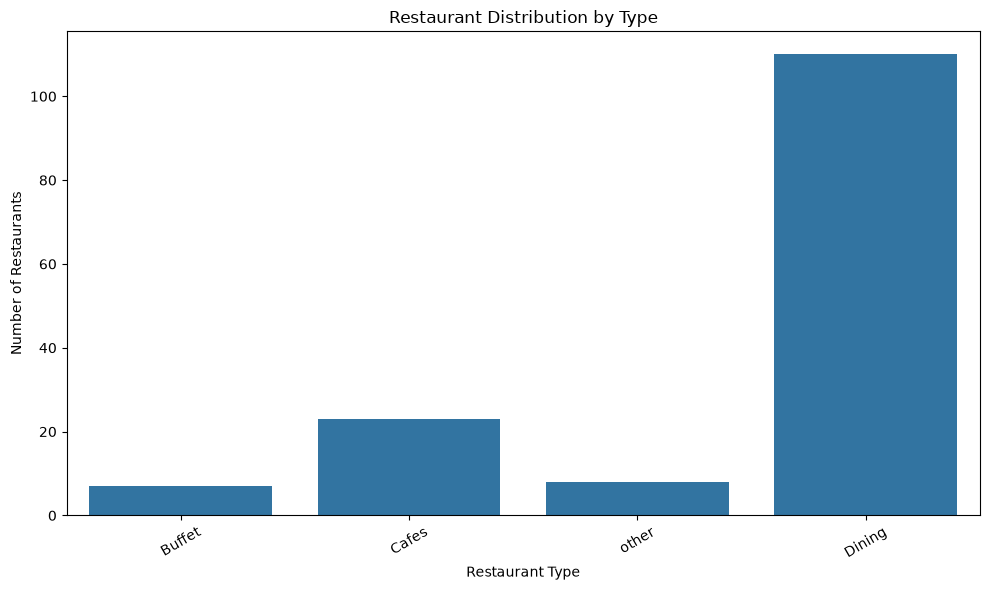

In [60]:
plt.figure(figsize=(10, 6))

sns.countplot(
    x='listed_in(type)',
    data=df
)

plt.title('Restaurant Distribution by Type')
plt.xlabel('Restaurant Type')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig('../images/restaurant_type_distribution.png',
            dpi=300, bbox_inches='tight')

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../images/customer_votes_by_type.png'

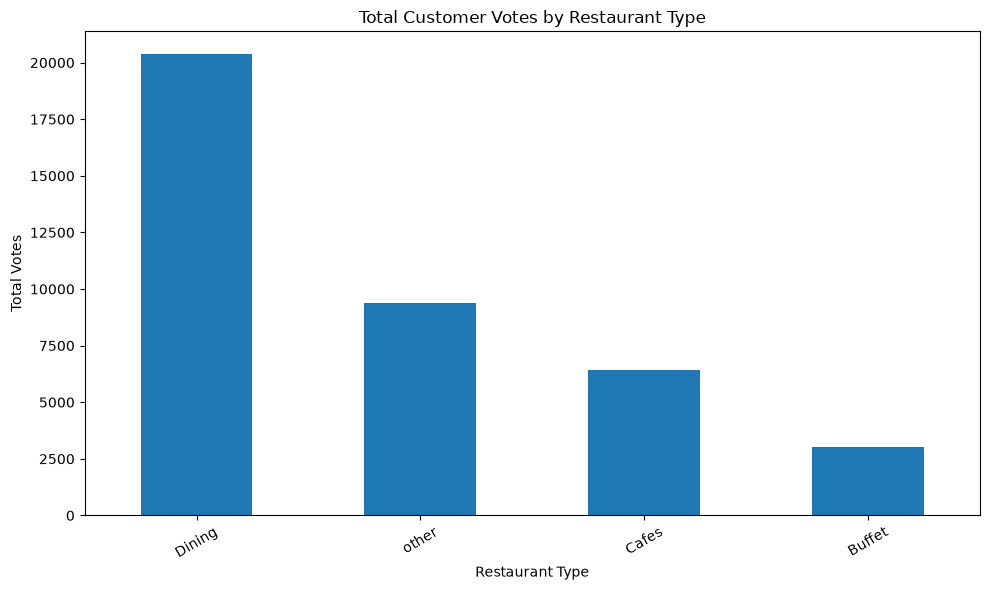

In [61]:
votes_by_type = (
    df.groupby('listed_in(type)')['votes']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

votes_by_type.plot(kind='bar')

plt.title('Total Customer Votes by Restaurant Type')
plt.xlabel('Restaurant Type')
plt.ylabel('Total Votes')
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig('../images/customer_votes_by_type.png',
            dpi=300, bbox_inches='tight')

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../images/rating_distribution.png'

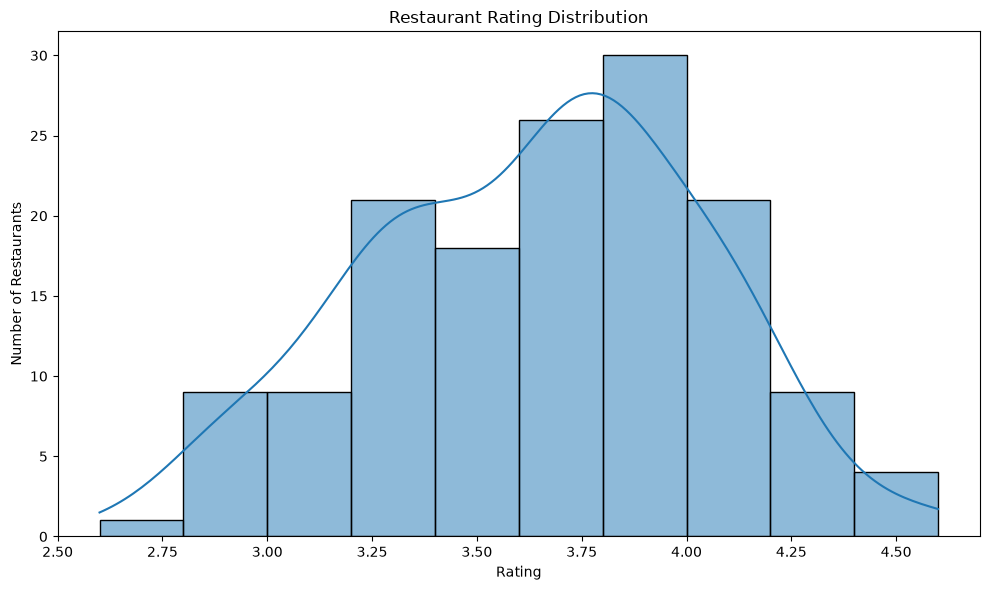

In [62]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['rate'],
    bins=10,
    kde=True
)

plt.title('Restaurant Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.tight_layout()

plt.savefig('../images/rating_distribution.png',
            dpi=300, bbox_inches='tight')

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../images/online_ordering.png'

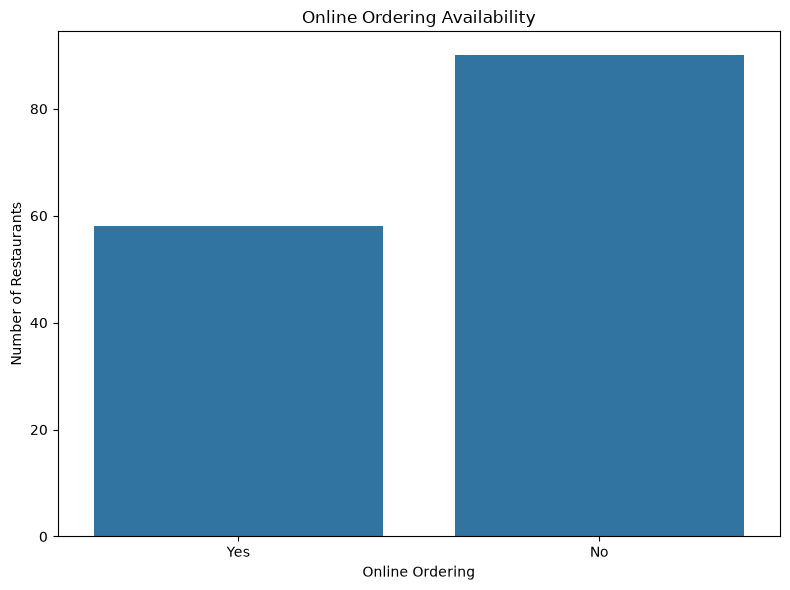

In [63]:
plt.figure(figsize=(8, 6))

sns.countplot(
    x='online_order',
    data=df
)

plt.title('Online Ordering Availability')
plt.xlabel('Online Ordering')
plt.ylabel('Number of Restaurants')
plt.tight_layout()

plt.savefig('../images/online_ordering.png',
            dpi=300, bbox_inches='tight')

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../images/price_category_vs_rating.png'

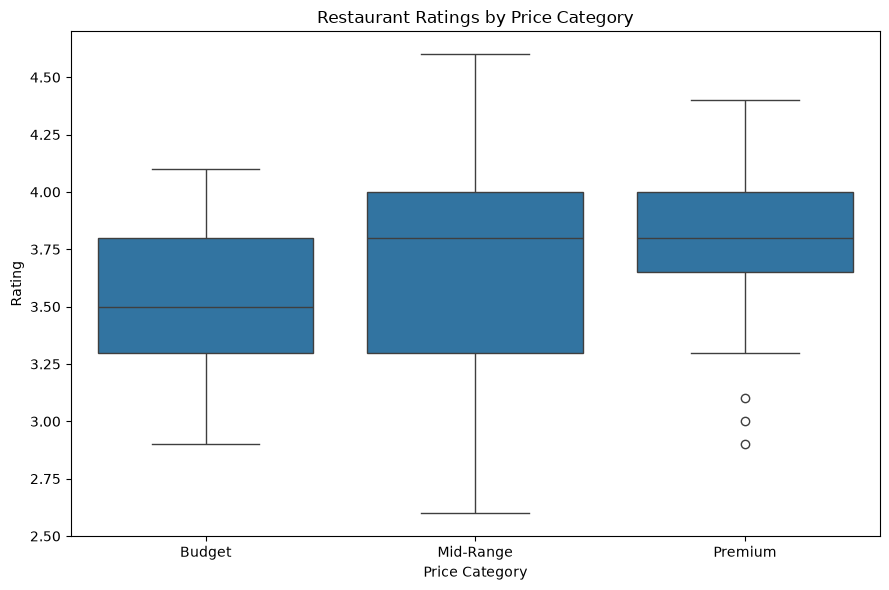

In [64]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    x='price_category',
    y='rate',
    data=df,
    order=['Budget', 'Mid-Range', 'Premium']
)

plt.title('Restaurant Ratings by Price Category')
plt.xlabel('Price Category')
plt.ylabel('Rating')
plt.tight_layout()

plt.savefig('../images/price_category_vs_rating.png',
            dpi=300, bbox_inches='tight')

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../images/rating_vs_votes.png'

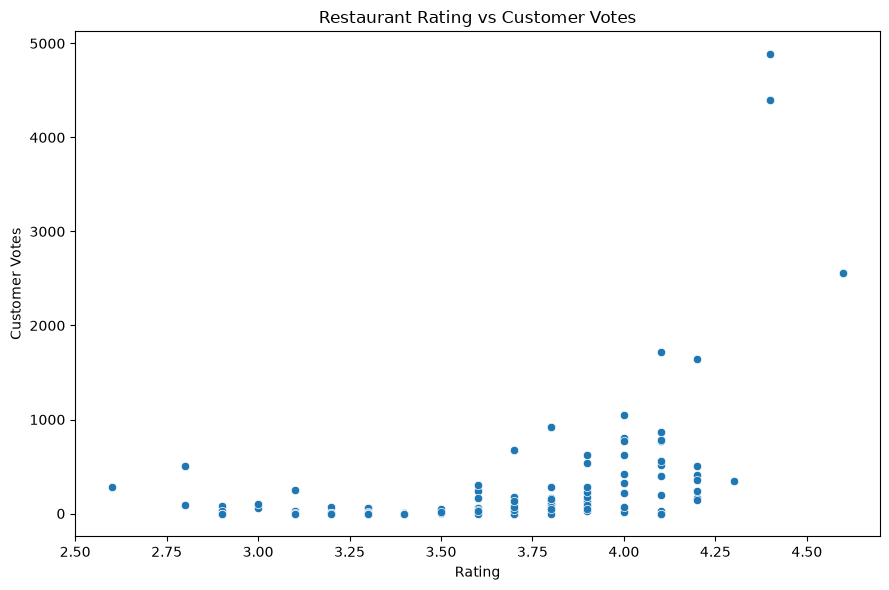

In [66]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    x='rate',
    y='votes',
    data=df
)

plt.title('Restaurant Rating vs Customer Votes')
plt.xlabel('Rating')
plt.ylabel('Customer Votes')
plt.tight_layout()

plt.savefig('../images/rating_vs_votes.png',
            dpi=300, bbox_inches='tight')

plt.show()